In [16]:
import matplotlib.pyplot as plt
from os import walk
import json
import numpy as np 
import os

In [56]:
mypath_cache = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/cache-results/output-vgg_16-M01-1000-sort'
mypath_origin = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/origin-results/output-vgg_16-O01'

values = {}
values_acc = {}
for (dir_path, dir_names, file_names) in walk(mypath_cache):
    for filename in file_names:
        if("output" not in filename):
            with open(os.path.join(dir_path, filename), 'r') as f:
                best = 100000
                count = 0
                s = 0
                for l in f:
                    result = json.loads(l)
                    task = result['i'][0][0]
                    r = sum(result['r'][0])/len(result['r'][0])

                    if(r > 1000):
                        continue
                    
                    if(task not in values):
                        values[task] = []
                        values_acc[task] = []
                    if(r < best):
                        best = r
                    if(best < 1000):
                        values[task].append(best)
                    if(r < 1000):
                        s += r
                        values_acc[task].append(s)

                    count += 1

values_ = {}
values_acc_ = {}
for (dir_path, dir_names, file_names) in walk(mypath_origin):
    for filename in file_names:
        if("output" not in filename):
            with open(os.path.join(dir_path, filename), 'r') as f:
                best = 100000
                count = 0
                s = 0
                for l in f:
                    result = json.loads(l)
                    task = result['i'][0][0]
                    r = sum(result['r'][0])/len(result['r'][0])

                    if(task not in values_):
                        values_[task] = []
                        values_acc_[task] = []
                    if(r < best):
                        best = r
                    if(best < 1000):
                        values_[task].append(best)
                    if(r < 1000):
                        s += r
                        values_acc_[task].append(s)

                    count += 1

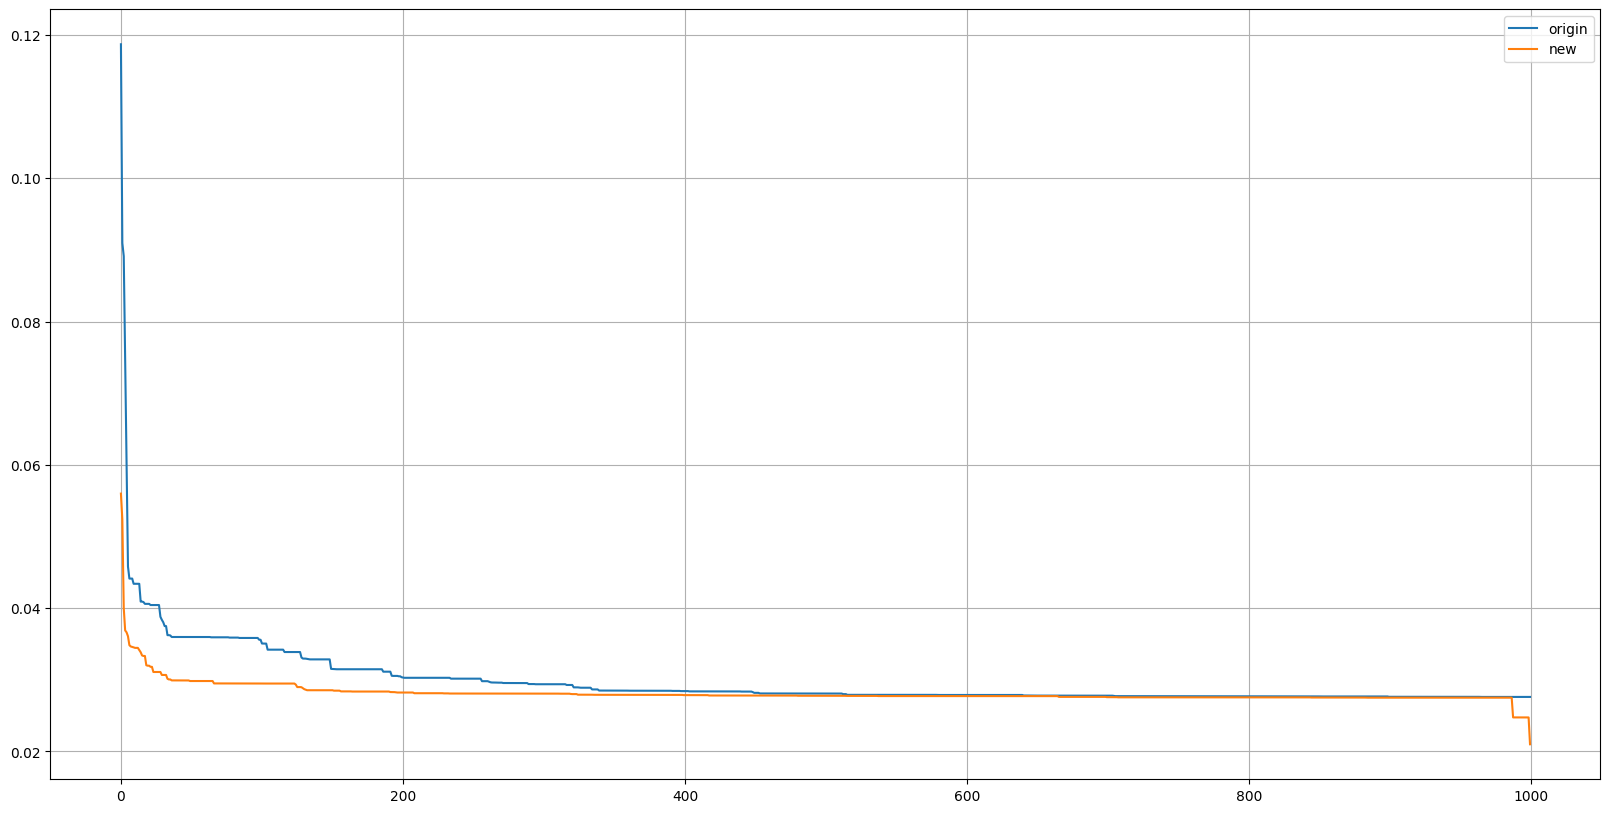

In [62]:
result_n = np.zeros(1000)
result_cn = np.zeros(1000)
result_o = np.zeros(1000)
result_co = np.zeros(1000)

for idx, task in enumerate(values):
    if(len(values[task])):
        for idx, value in enumerate(values[task][:1000]):
            result_n[idx] += value
            result_cn[idx] += 1
        for idx, value in enumerate(values_[task][:1000]):
            result_o[idx] += value
            result_co[idx] += 1

#for idx, value in enumerate(result_n):
#    result_n[idx] = result_n[idx] / result_cn[idx]
#for idx, value in enumerate(result_o):
#    result_o[idx] = result_o[idx] / result_co[idx]
    
plt.figure(figsize=(20, 10))
plt.plot(result_o, label="origin")
plt.plot(result_n, label="new")
plt.grid()
plt.legend()

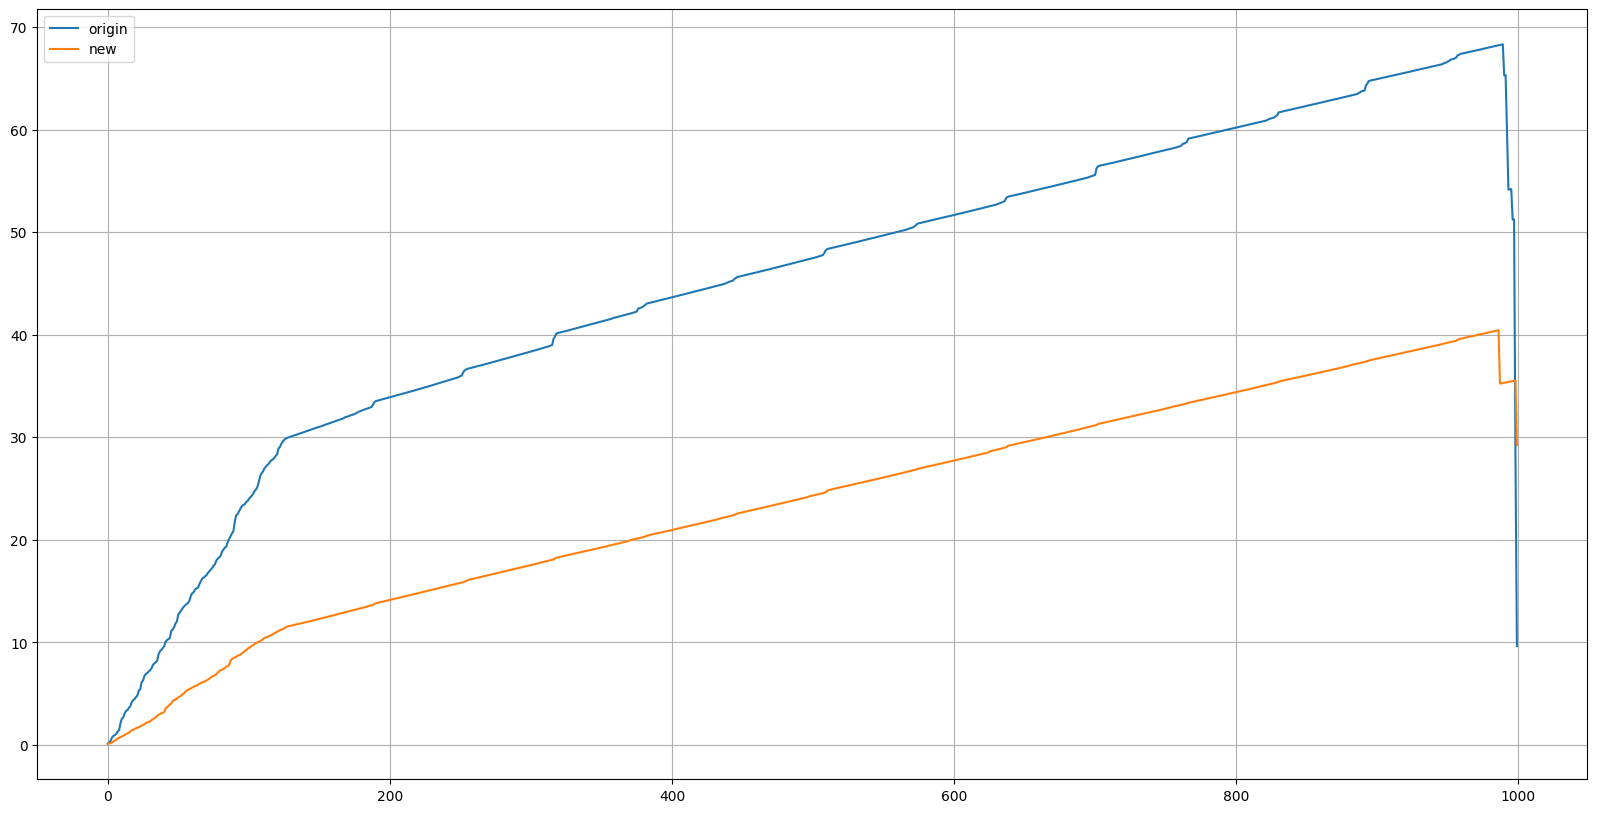

In [61]:
result_n = np.zeros(1000)
result_cn = np.zeros(1000)
result_o = np.zeros(1000)
result_co = np.zeros(1000)

for idx, task in enumerate(values_acc):
    if(len(values_acc[task])):
        for idx, value in enumerate(values_acc[task][:1000]):
            result_n[idx] += value
            result_cn[idx] += 1
        for idx, value in enumerate(values_acc_[task][:1000]):
            result_o[idx] += value
            result_co[idx] += 1

#for idx, value in enumerate(result_n):
#    result_n[idx] = result_n[idx] / result_cn[idx]
#for idx, value in enumerate(result_o):
#    result_o[idx] = result_o[idx] / result_co[idx]
    
plt.figure(figsize=(20, 10))
plt.plot(result_o, label="origin")
plt.plot(result_n, label="new")
plt.grid()
plt.legend()